In [307]:
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.linear_model import Perceptron
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_blobs

# Part I – Importing the Dataset and Select Versicolor and Virginica (3 pts.)

### 1.) Generate a dataset using sklearn.datasets.make_blobs with 150 samples, 2 features and centers, cluster standard deviation of 3.5, and random_state=1 (Review Lab. Act. 2).


In [308]:
X, y = make_blobs(n_samples=150, centers=2, n_features=2, random_state=1,cluster_std=3.5) 

print("length of X:",len(X),"\nLength of y:",len(y))
print(X,"\n\n",y)

length of X: 150 
Length of y: 150
[[-13.90535757  -3.67010369]
 [ -8.49437101  -6.07784294]
 [ -8.27453456  -6.33572204]
 [-12.26192091  -0.79814443]
 [ -1.79499419  -1.24871337]
 [  2.79858585  11.29134599]
 [ -1.38718596   6.57082079]
 [-11.74145998  -5.04179597]
 [-14.13582595  -6.28348936]
 [ -5.0713225   -3.50149302]
 [ -9.02996494  -6.51979916]
 [-11.90792209  -4.64928107]
 [ -9.12691544  -4.99159258]
 [ -2.81860545  -1.90353155]
 [  2.30863314   0.55687043]
 [-14.26681789   4.61944172]
 [ -8.26447287  -4.56480961]
 [ -8.23656566   0.57294204]
 [ -2.31255411   4.05037931]
 [ -2.73127395   7.30440112]
 [-10.88734204   0.94610525]
 [ -5.51172703   8.41302285]
 [ -1.23900357   6.56670075]
 [ -2.43770841   3.70383663]
 [-11.14046075  -8.65271381]
 [ -0.60896379   3.17361541]
 [ -2.0896757    1.13129685]
 [ -0.43264898  -0.18650207]
 [ -1.51181179   6.44634312]
 [-11.96578151   2.88872472]
 [-19.77351      2.8280023 ]
 [-10.00433269  -8.84152003]
 [ -8.71555045  -7.60941138]
 [ -0.17

### 2.) Visualize the data by graphing using matplot. Emphasize the class label of the different data points by using two colors for the two different class labels.

     feature_1  feature_2  class_label
0   -13.905358  -3.670104            1
1    -8.494371  -6.077843            1
2    -8.274535  -6.335722            1
3   -12.261921  -0.798144            1
7   -11.741460  -5.041796            1
..         ...        ...          ...
141 -10.419339  -8.269271            1
142  -6.097372  -6.006182            1
143  -3.331407  -0.064650            1
146  -7.691038  -9.649383            1
147 -15.775237  -7.070293            1

[75 rows x 3 columns]


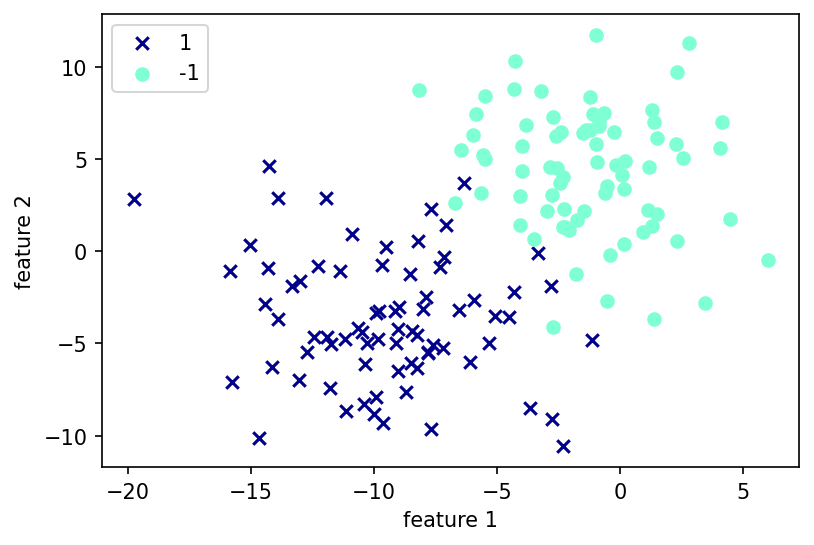

In [309]:
j = {'feature_1':X[:,0],'feature_2':X[:,1],'class_label':y}
df = pd.DataFrame(j)
dg = df.query('class_label == 1')
dh = df.query('class_label == 0')

print(dg)

plt.scatter(dg.feature_1, dg.feature_2, c='darkblue', marker='x',label='1')
plt.scatter(dh.feature_1, dh.feature_2, c='aquamarine',marker='o',label='-1')

plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.legend(loc='upper left')
plt.show()

Part II – Training the SVM  (5 pts.)

# Part II – Training the SVM

### 1. Split the dataset to training data and test set with 30% test size and random state 1.



In [310]:
#y = df.species
#X = df.drop("species", axis=1)
#y = np.where( species == 'Iris-versicolor' ,0,1)

# splitting data set with 30% test size and random state 1 for reproducibility
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=1, stratify=y)

#print("X data type\n\n",X.dtypes,"\n\ny data type\n\n", y.dtypes)
#print("length of X_train:",len(X_train),"\nlength of X_test:", len(X_test),"\nlength of y_train:", len(y_train),"\nlength of y_test:", len(y_test))
print("array X(training data set) has the values:\n\n",X,"\n\narray y(class label) has the values:\n\n", y)


array X(training data set) has the values:

 [[-13.90535757  -3.67010369]
 [ -8.49437101  -6.07784294]
 [ -8.27453456  -6.33572204]
 [-12.26192091  -0.79814443]
 [ -1.79499419  -1.24871337]
 [  2.79858585  11.29134599]
 [ -1.38718596   6.57082079]
 [-11.74145998  -5.04179597]
 [-14.13582595  -6.28348936]
 [ -5.0713225   -3.50149302]
 [ -9.02996494  -6.51979916]
 [-11.90792209  -4.64928107]
 [ -9.12691544  -4.99159258]
 [ -2.81860545  -1.90353155]
 [  2.30863314   0.55687043]
 [-14.26681789   4.61944172]
 [ -8.26447287  -4.56480961]
 [ -8.23656566   0.57294204]
 [ -2.31255411   4.05037931]
 [ -2.73127395   7.30440112]
 [-10.88734204   0.94610525]
 [ -5.51172703   8.41302285]
 [ -1.23900357   6.56670075]
 [ -2.43770841   3.70383663]
 [-11.14046075  -8.65271381]
 [ -0.60896379   3.17361541]
 [ -2.0896757    1.13129685]
 [ -0.43264898  -0.18650207]
 [ -1.51181179   6.44634312]
 [-11.96578151   2.88872472]
 [-19.77351      2.8280023 ]
 [-10.00433269  -8.84152003]
 [ -8.71555045  -7.60941138

### 2. Implement the feature scaling method.



In [311]:
sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

print(y_train)
#print(X_train_std)

[1 0 1 1 1 0 1 1 1 0 0 0 0 1 1 1 0 0 1 0 1 0 1 0 0 1 0 0 1 0 0 1 1 1 1 1 0
 1 1 1 0 1 0 1 0 0 1 0 1 0 1 1 0 1 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1 0
 1 1 1 1 0 0 0 1 1 1 0 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 0 0 0 0 0]


### 3. Train the SVM by fitting the train data set using the SVC class and fit method from the sklearn.svm with RBF (Radial Basis Function) Kernel. Choose an appropriate value for gamma and C which will give you a high accuracy but will not overfit the dataset. Use random_state=1.

In [312]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', random_state=1, C=0.1, gamma=0.07)
svm.fit(X_train_std, y_train)

SVC(C=0.1, gamma=0.07, random_state=1)

# Part IV – Evaluate the SVM Model

### 1. Count the number of misclassified samples.



In [313]:
y_pred = svm.predict(X_test_std)
print('Misclassified samples: %d' % (y_test != y_pred).sum())
#print(y_test != y_pred)

Misclassified samples: 2


### 2. Print the accuracy of the SVM model with RBF kernel.

In [314]:
from sklearn.metrics import accuracy_score

print('Accuracy: %.2f' % accuracy_score(y_test, y_pred))
print('Accuracy: %.2f' % svm.score(X_test_std, y_test))

Accuracy: 0.96
Accuracy: 0.96


# Part IV – Plotting the decision regions and the Data  (15 pts.)

### 1. Plot the different decision regions using Matplot. 

### 2. Visualize how well the decision regions separate the different samples in the plot. Use different colors and markers for the different class types for the scatter plot of the samples.

### 3. Highlight the test samples by encircling them.

### 4. Highlight the misclassified samples in the test by encircling them with red.

### 5. Put a legend that labels the class types of the different shapes in the scatter plot.


<ipython-input-326-bc52b35249b3>:30: MatplotlibDeprecationWarning: Using a string of single character colors as a color sequence is deprecated since 3.2 and will be removed two minor releases later. Use an explicit list instead.
  plt.scatter(X_test[:, 0], X_test[:, 1], c='', edgecolor='black', alpha=1.0,
<ipython-input-326-bc52b35249b3>:34: MatplotlibDeprecationWarning: Using a string of single character colors as a color sequence is deprecated since 3.2 and will be removed two minor releases later. Use an explicit list instead.
  plt.scatter(X_test[[13,43], 0], X_test[[13,43], 1], c='', edgecolor='red', alpha=1.0,


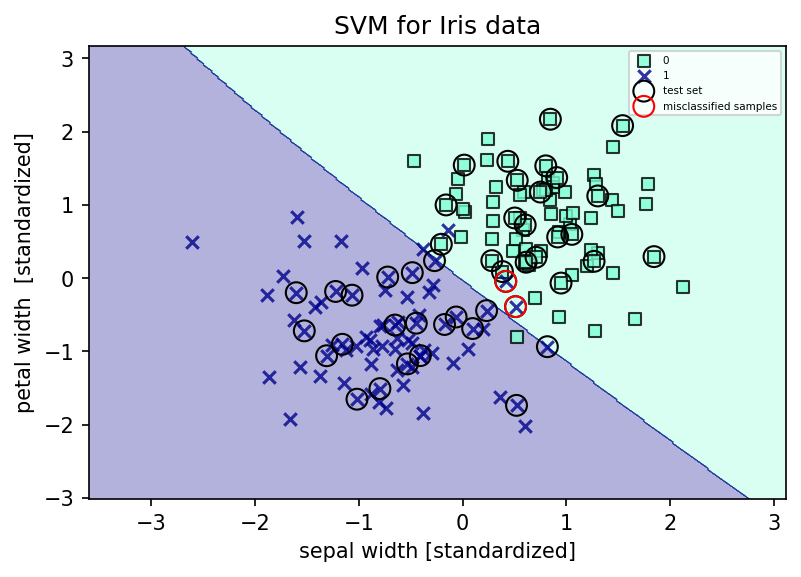

In [326]:
def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):
    # setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('aquamarine', 'darkblue','cyan', 'darkorange', 'lime')
    cmap = ListedColormap(colors[:len(np.unique(y))])
    
    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
    np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    plt.title('SVM for Iris data')
    
    #highlight test samples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1], alpha=0.8, c=colors[idx],
                    marker=markers[idx], label=cl, edgecolor='black')
        
    # highlight test samples - emphasize test samples
    if test_idx:
        # plot all samples
        X_test, y_test = X[test_idx, :], y[test_idx]
        plt.scatter(X_test[:, 0], X_test[:, 1], c='', edgecolor='black', alpha=1.0,
                    linewidth=1, marker='o', s=100, label='test set')
    
        # highlighting the missclassified sample
        plt.scatter(X_test[[13,43], 0], X_test[[13,43], 1], c='', edgecolor='red', alpha=1.0,
                       linewidth=1, marker='o', s=100, label='misclassified samples')


X_combined_std = np.vstack((X_train_std, X_test_std))
y_combined = np.hstack((y_train, y_test))  

plt.rcParams['figure.dpi'] = 150
plot_decision_regions(X=X_combined_std, y=y_combined, classifier=svm, test_idx=range(105,150))
plt.xlabel('sepal width [standardized]')
plt.ylabel('petal width  [standardized]')
plt.legend(loc = 'upper right',prop={"size":5})
plt.show()

In [325]:
# use this to check the error rows for printing

pred_array = [y_test, y_pred, y_test != y_pred ]
dg = pd.DataFrame(y_pred)
dg = dg.assign(y_test = pd.Series(y_test).values)
dg = dg.assign(missclassified = pd.Series(y_test != y_pred).values)
dg = dg.assign(x_test_std_0 = pd.Series(X_test_std[:,0]).values)
dg = dg.assign(x_test_std_1 = pd.Series(X_test_std[:,1]).values)
print(dg)

    0  y_test  missclassified  x_test_std_0  x_test_std_1
0   0       0           False      1.302930      1.121886
1   1       1           False     -0.721094      0.015659
2   1       1           False     -1.601999     -0.198004
3   1       1           False     -1.017030     -1.651074
4   0       0           False      0.436279      1.594786
5   1       1           False     -1.309666     -1.058213
6   1       1           False     -1.157930     -0.901890
7   0       0           False      0.750717      1.174495
8   1       1           False     -0.406674     -1.056541
9   0       0           False      0.707774      0.285055
10  0       0           False      0.907103      1.372510
11  0       0           False     -0.204357      0.462354
12  0       0           False      0.846269      2.168378
13  0       1            True      0.510800     -0.388063
14  0       0           False     -0.158737      0.999187
15  1       1           False      0.231779     -0.442374
16  0       0 